In [ ]:
%pwd
%load_ext autoreload
%autoreload 2

In [1]:
import os
import sys

mvae_dir = os.path.split(os.getcwd())[0]
if mvae_dir not in sys.path:
    sys.path.append(mvae_dir)
    
import torch
import numpy as np
import torch.optim as optim

import lib.dataloaders.synthetic_loader as dataloader
import lib.models.vae.euclidean_vae as model
import lib.trainer as trainer
import lib.utils as utils

from configs.nested_spheres_configs import all_configs

In [2]:
torch.manual_seed(42)
np.random.seed(42)

----------------------------------------------------------------
Running exp1a_nested_spheres with latent_dim=exp1a_scrunchy: low embedding dim + noise
----------------------------------------------------------------
TRANSLATION tensor([90.2818, 71.3890, 31.5716, 76.3090,  9.3104, 83.4477, 64.4846, 88.3272,
        93.0158, 16.4020])
Trainer successfully initialized.
Training the gaussianVAE model.
Epoch 1/15, Train Loss: 16933.7926, Test Loss: 92.6971
--------------------------------------------------
Epoch 2/15, Train Loss: 74.1436, Test Loss: 67.8058
--------------------------------------------------
Epoch 3/15, Train Loss: 66.6536, Test Loss: 64.1924
--------------------------------------------------
Epoch 4/15, Train Loss: 61.1634, Test Loss: 57.9325
--------------------------------------------------
Epoch 5/15, Train Loss: 57.9893, Test Loss: 57.2710
--------------------------------------------------
Epoch 6/15, Train Loss: 57.6588, Test Loss: 57.2823
----------------------------

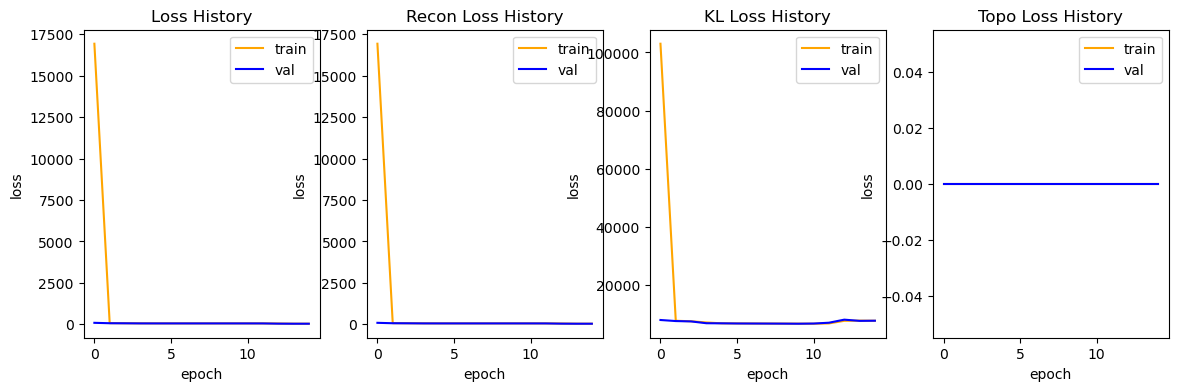

Forwarding data through model...


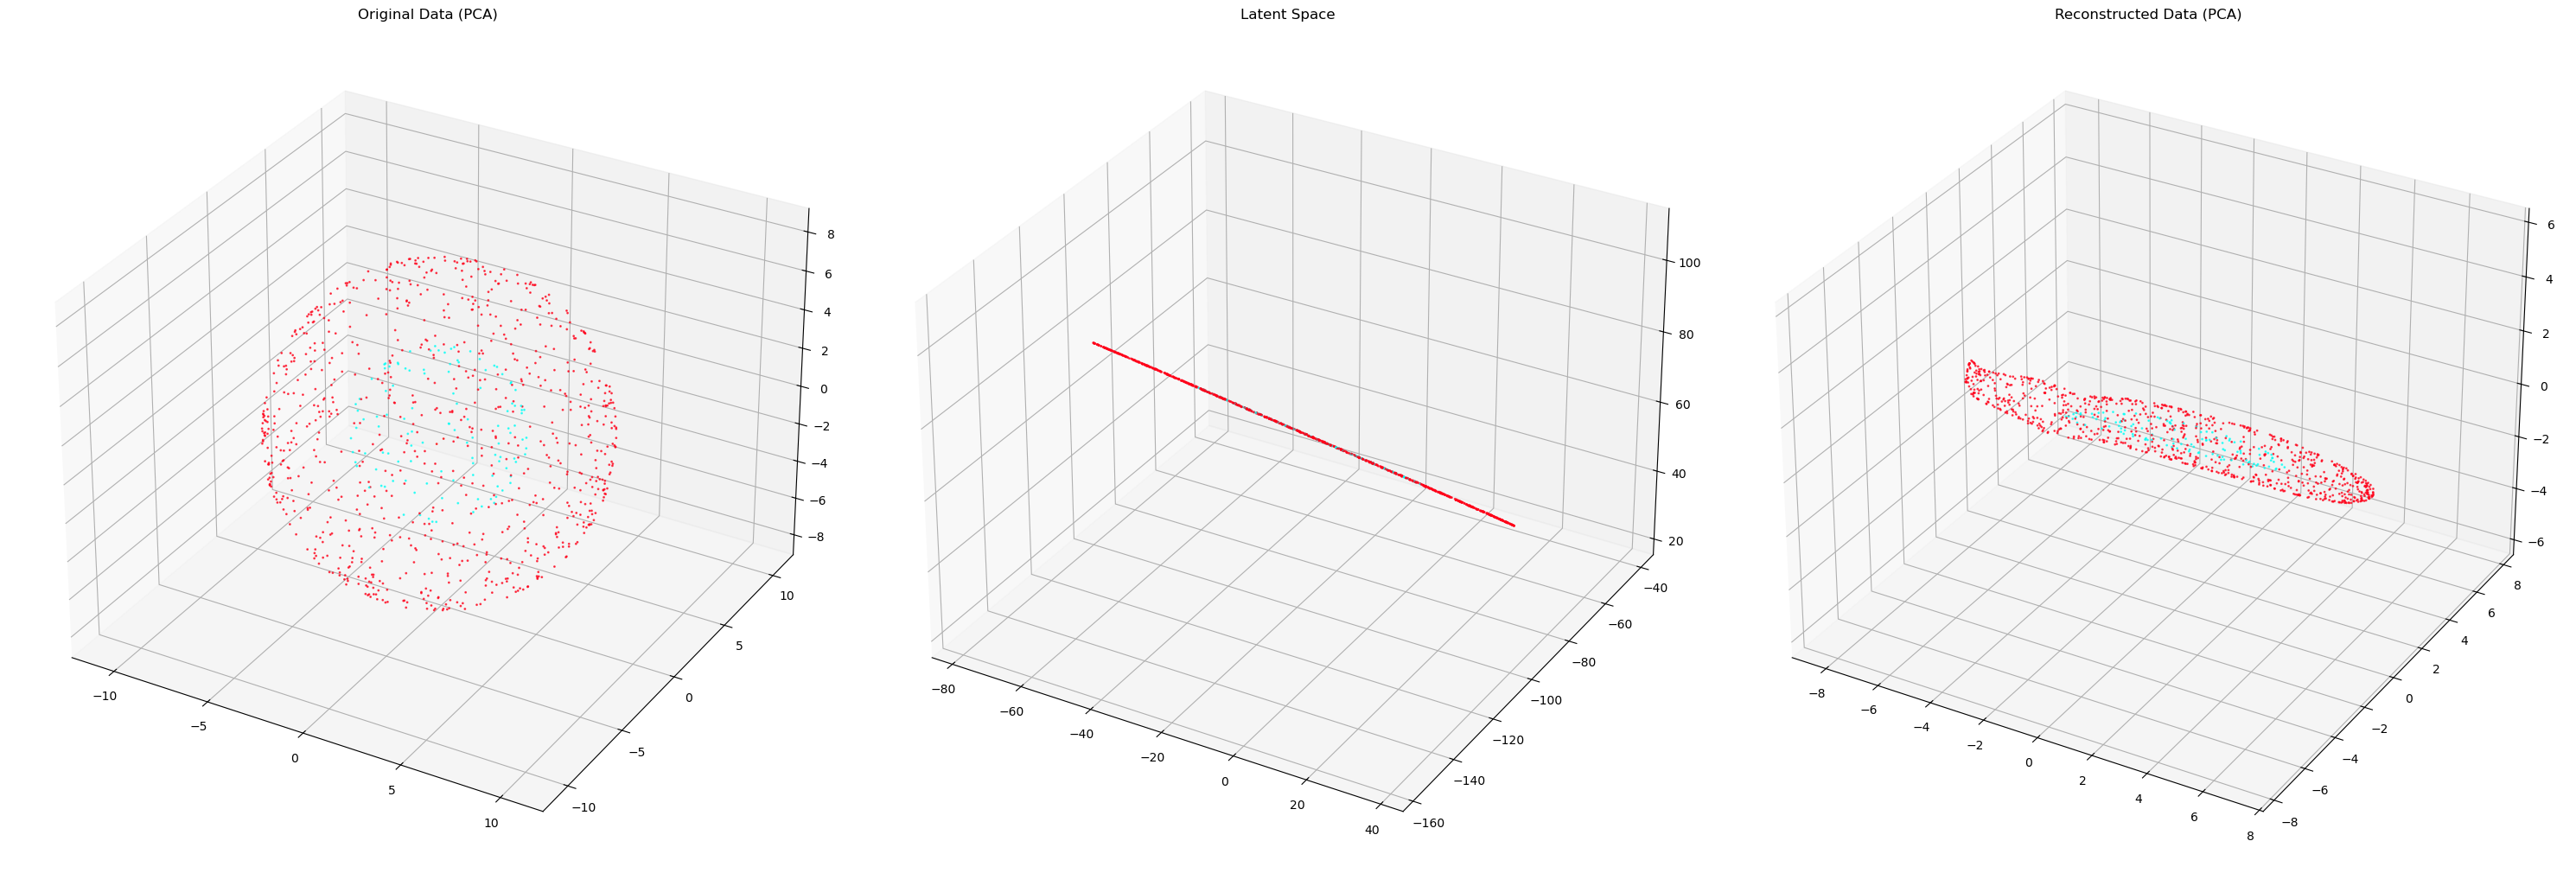

----------------------------------------------------------------
Running exp1b_nested_spheres with latent_dim=exp1b_scrunchy: low embedding dim + noise
----------------------------------------------------------------
TRANSLATION tensor([39.3019, 22.5422, 52.7269, 18.0057, 94.6972, 85.2378, 60.3415, 88.4127,
        30.4594,  0.9193])
Trainer successfully initialized.
Training the gaussianVAE model.
Epoch 1/15, Train Loss: 0.0030, Test Loss: 0.0005
--------------------------------------------------
Epoch 2/15, Train Loss: 0.0005, Test Loss: 0.0010
--------------------------------------------------
Epoch 3/15, Train Loss: 0.0005, Test Loss: 0.0003
--------------------------------------------------
Epoch 4/15, Train Loss: 0.0005, Test Loss: 0.0009
--------------------------------------------------
Epoch 5/15, Train Loss: 0.0005, Test Loss: 0.0009
--------------------------------------------------
Epoch 6/15, Train Loss: 0.0004, Test Loss: 0.0006
-------------------------------------------

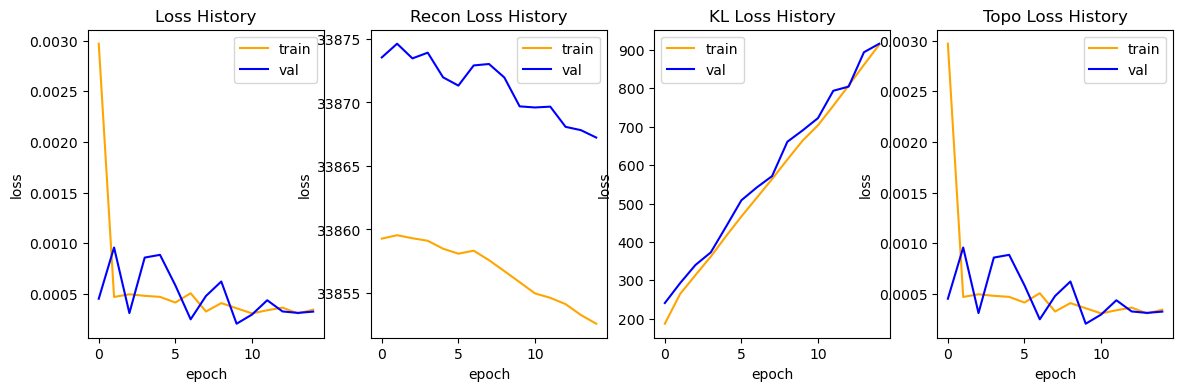

Forwarding data through model...


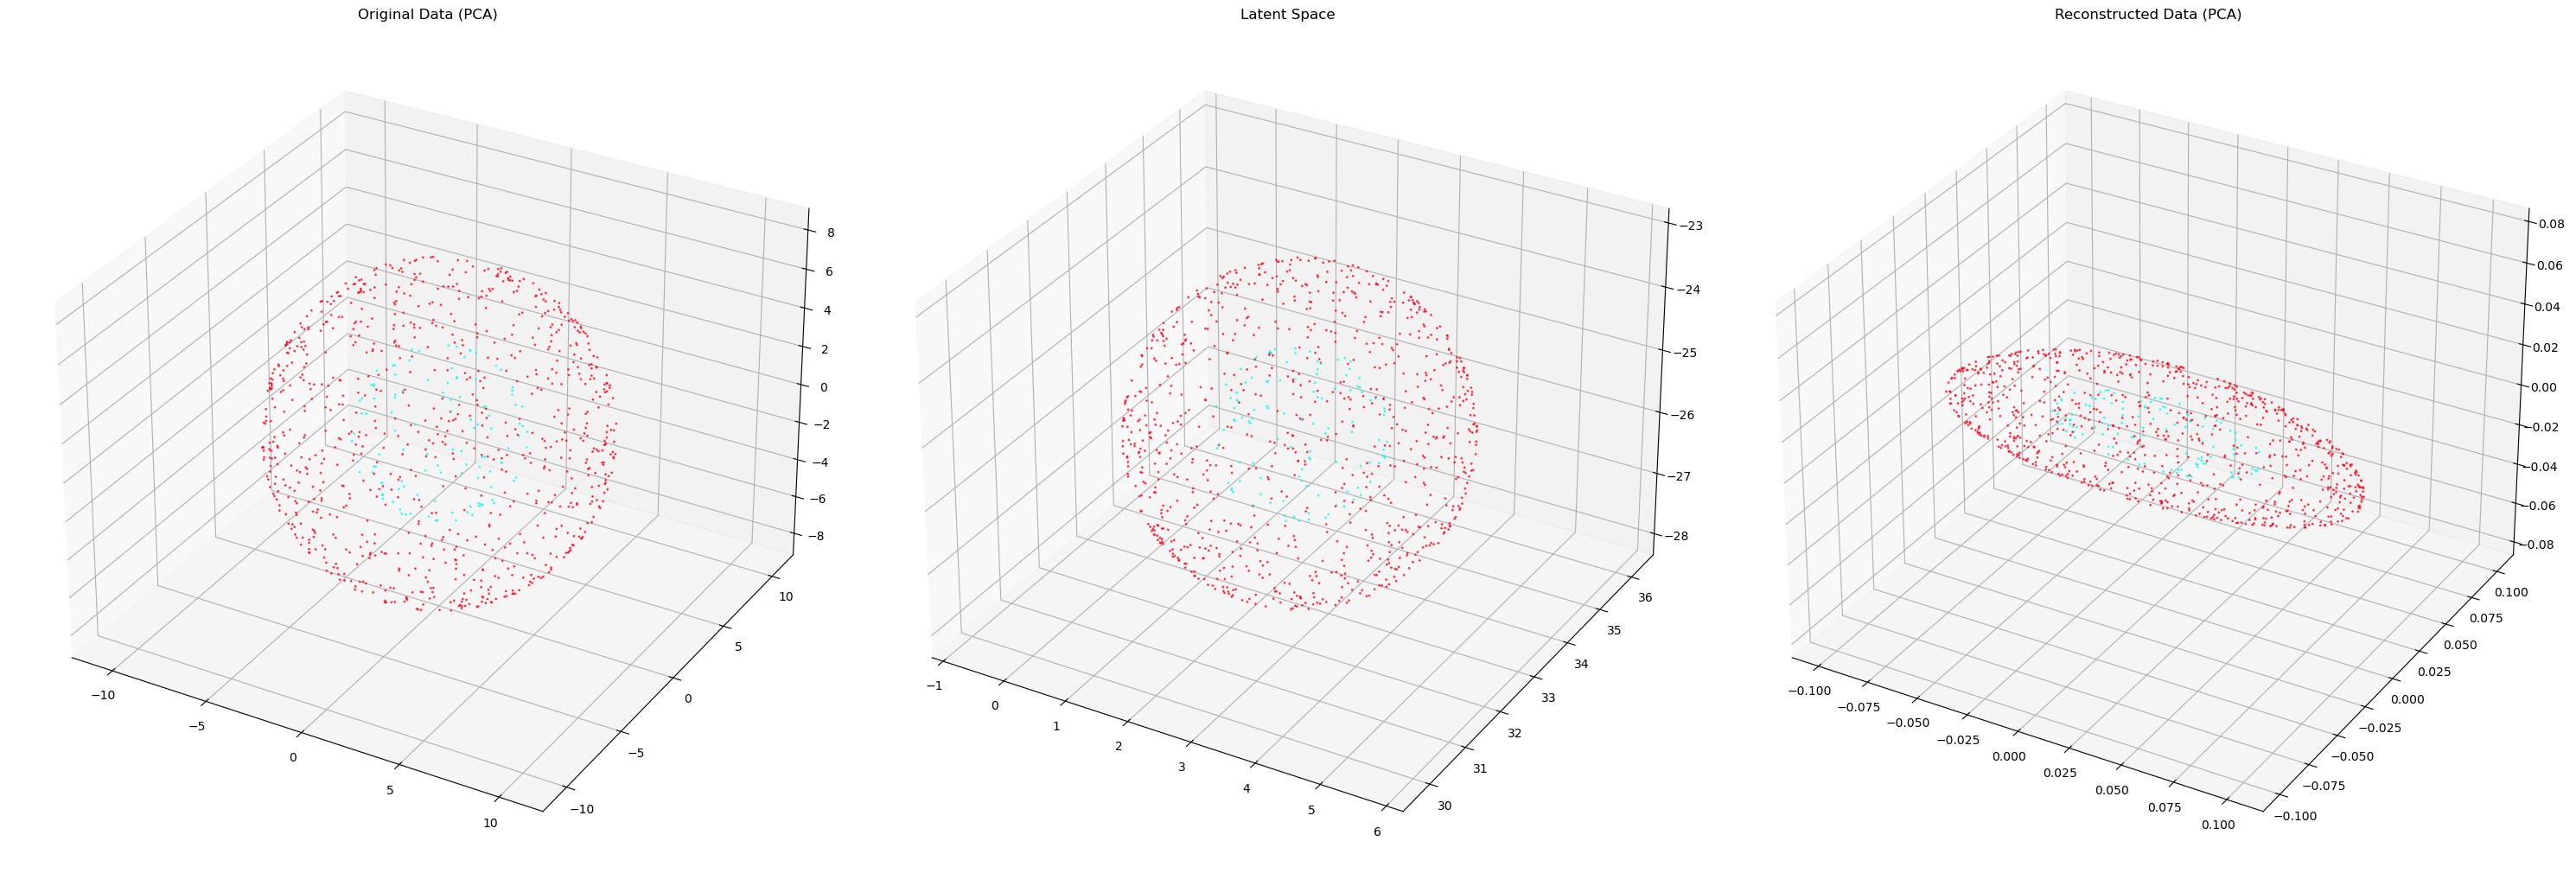

----------------------------------------------------------------
Running exp1c_nested_spheres with latent_dim=exp1c_scrunchy: low embedding dim + noise
----------------------------------------------------------------
TRANSLATION tensor([ 8.5943, 61.6172, 55.1854, 22.7701, 44.2341, 69.6003, 30.7835, 71.3778,
        75.5221, 46.3153])
Trainer successfully initialized.
Training the gaussianVAE model.
Epoch 1/15, Train Loss: 0.0084, Test Loss: 0.0043
--------------------------------------------------
Epoch 2/15, Train Loss: 0.0047, Test Loss: 0.0048
--------------------------------------------------
Epoch 3/15, Train Loss: 0.0043, Test Loss: 0.0053
--------------------------------------------------
Epoch 4/15, Train Loss: 0.0043, Test Loss: 0.0048
--------------------------------------------------
Epoch 5/15, Train Loss: 0.0047, Test Loss: 0.0045
--------------------------------------------------


/home/timtom/miniconda3/envs/mvae-env/lib/python3.9/site-packages/gph/python/ripser_interface.py:617: RuntimeWarning: overflow encountered in cast
  DParam = squareform(dm, checks=False).astype(np.float32)


Epoch 6/15, Train Loss: 0.0045, Test Loss: 0.0040
--------------------------------------------------
Epoch 7/15, Train Loss: 0.0042, Test Loss: 0.0053
--------------------------------------------------
Epoch 8/15, Train Loss: 0.0047, Test Loss: 0.0045
--------------------------------------------------
Epoch 9/15, Train Loss: 0.0045, Test Loss: 0.0043
--------------------------------------------------
Epoch 10/15, Train Loss: 0.0047, Test Loss: 0.0048
--------------------------------------------------
Epoch 11/15, Train Loss: 0.0047, Test Loss: 0.0046
--------------------------------------------------
Epoch 12/15, Train Loss: 0.0044, Test Loss: 0.0048
--------------------------------------------------
Epoch 13/15, Train Loss: 0.0045, Test Loss: 0.0055
--------------------------------------------------
Epoch 14/15, Train Loss: 0.0046, Test Loss: 0.0039
--------------------------------------------------
Epoch 15/15, Train Loss: 0.0045, Test Loss: 0.0041
-----------------------------------

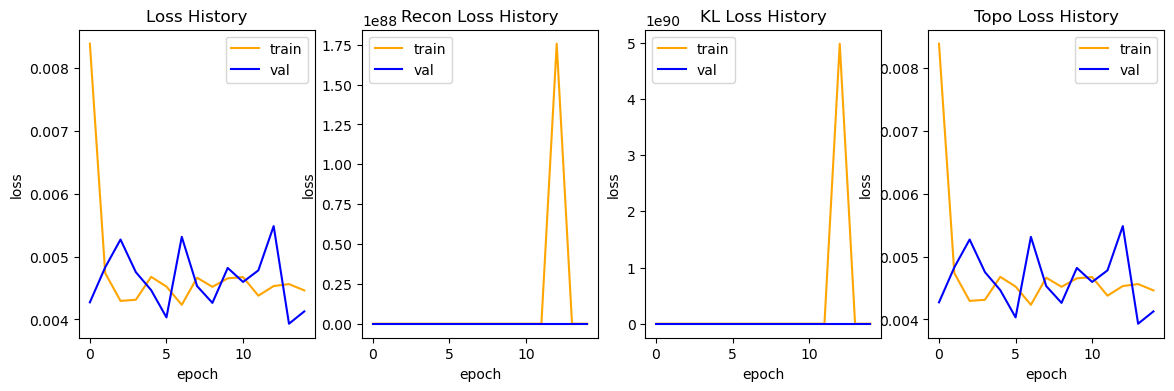

Forwarding data through model...


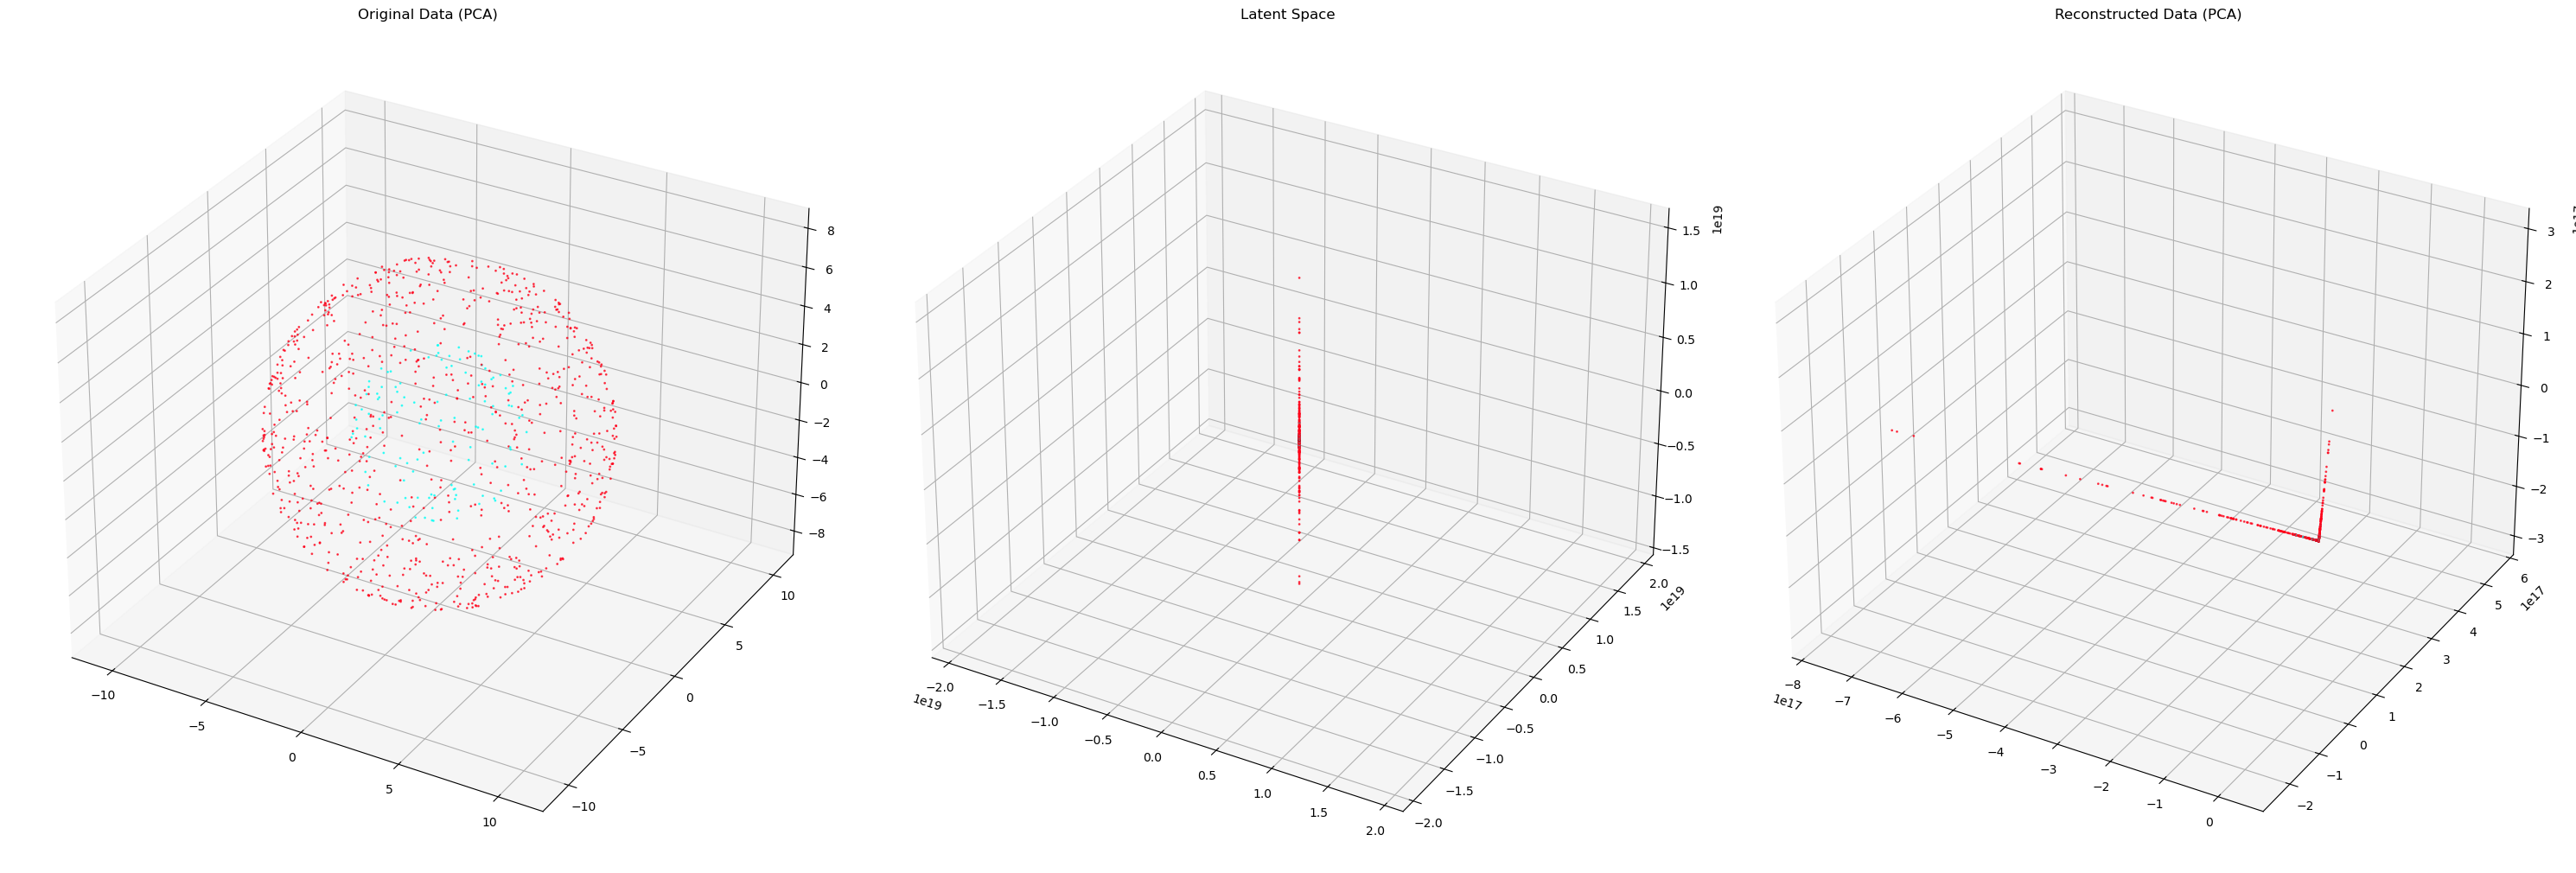

----------------------------------------------------------------
Running exp1d_nested_spheres with latent_dim=exp1d_scrunchy: low embedding dim + noise
----------------------------------------------------------------
TRANSLATION tensor([63.4108, 54.6876, 81.3353, 22.3187, 21.6615, 21.4269,  9.8747, 63.9650,
        56.7794, 27.4702])
Trainer successfully initialized.
Training the gaussianVAE model.
Epoch 1/15, Train Loss: 0.0020, Test Loss: 0.0016
--------------------------------------------------


KeyboardInterrupt: 

In [3]:
for name, config in all_configs.items():
    print("----------------------------------------------------------------")
    print(f"Running {name} with latent_dim={config.experiment}")
    print("----------------------------------------------------------------")
    data_loader = dataloader.load_synthetic_ds(config)
    train_loader, test_loader = data_loader
    vae_model = model.EuclideanVAE(config)
    optimizer = optim.Adam(vae_model.parameters(), lr=config.learning_rate)
    history = trainer.MVAETrainer(vae_model, data_loader, optimizer, config).train()
    utils.show_training_history(history)
    utils.plot_data_latents_recon(config, vae_model, train_loader)